In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

In [3]:
df = pd.read_csv("/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
x = df.drop("median_house_value", axis = 1)
y = df["median_house_value"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [7]:
x_train_ocean = pd.get_dummies(x_train.loc[ : , "ocean_proximity"], drop_first = True)
x_test_ocean = pd.get_dummies(x_test.loc[:, "ocean_proximity"], drop_first = True)

In [8]:
x_train.drop(["ocean_proximity"], axis = 1, inplace = True)
x_train = pd.concat([x_train, x_train_ocean], axis = 1)
x_test.drop(["ocean_proximity"], axis = 1, inplace = True)
x_test = pd.concat([x_test, x_test_ocean], axis = 1)

In [9]:
imputer = KNNImputer()
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [10]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
len(x_train[0])

12

In [12]:
model = Sequential()

model.add(Dense(
    64,
    activation="relu",
    input_dim=12,
    kernel_initializer="he_normal",
    kernel_regularizer = keras.regularizers.L2(1e-4)
))

model.add(BatchNormalization())

model.add(Dense(
    64,
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer = keras.regularizers.L2(1e-4)
))

model.add(BatchNormalization())

model.add(Dense(
    1,
    activation="linear",
    kernel_initializer="glorot_normal"
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1790399055.877266      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790399055.880495      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
adam = Adam(learning_rate = 0.1)
model.compile(loss = "mae", optimizer = adam, metrics = ["R2Score", "mse", "mae"])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 256 (1.00 KB)

In [15]:
history = model.fit(x_train, y_train, epochs = 100, validation_split = 0.2)

Epoch 1/100
 63/413 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - R2Score: -3.2105 - loss: 200220.0432 - mae: 200220.0424 - mse: 52599036651.6825

I0000 00:00:1790399061.017295     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - R2Score: -1.5174 - loss: 141135.3750 - mae: 141135.0000 - mse: 33477242880.0000 - val_R2Score: 0.4174 - val_loss: 57899.9570 - val_mae: 57898.7344 - val_mse: 7950356992.0000
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - R2Score: 0.5792 - loss: 51872.4492 - mae: 51870.4844 - mse: 5595467776.0000 - val_R2Score: 0.6587 - val_loss: 45712.0859 - val_mae: 45709.5156 - val_mse: 4657009664.0000
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - R2Score: 0.6782 - loss: 45742.1562 - mae: 45738.9961 - mse: 4278987008.0000 - val_R2Score: -0.0072 - val_loss: 50760.9531 - val_mae: 50756.9883 - val_mse: 13743902720.0000
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - R2Score: 0.6859 - loss: 44992.8281 - mae: 44988.4102 - mse: 4176414208.0000 - val_R2Score: -0.5018 - val_loss: 46029.8047 - val_mae: 46025.0430 - val_mse: 20493803520.0000
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - R2Score: 0.6874 - loss: 44869.5234 - mae: 44864.

In [17]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
pred = model.predict(x_test)
metrics = (r2_score(y_test, pred), mae(y_test, pred), mse(y_test, pred), rmse(y_test, pred))

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [18]:
print("RMSE : ", metrics[-1])
print("MSE : ", metrics[-2])
print("MAE : ", metrics[-3])
print("R2_score : ", metrics[0]) 

RMSE :  53051.90753395925
MSE :  2814504892.9917626
MAE :  33779.394600328545
R2_score :  0.7852193521468412


In [29]:
keys

dict_keys(['R2Score', 'loss', 'mae', 'mse', 'val_R2Score', 'val_loss', 'val_mae', 'val_mse'])

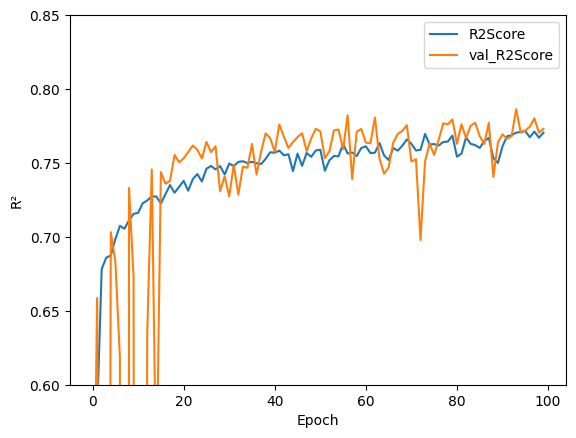

In [33]:
plt.plot(history.history['R2Score'], label="R2Score")
plt.plot(history.history['val_R2Score'], label="val_R2Score")

plt.ylim(0.6, 0.85)
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.legend()
plt.show()